In [20]:
import logging

logger = logging.getLogger("cmdstanpy")
logger.setLevel(logging.CRITICAL)
logger.propagate = False
logger.handlers = []
logger.disabled = True
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
# %matplotlib notebook
import glob
import cmdstanpy
from bayes_drt2.inversion import Inverter
import bayes_drt2.file_load as fl
import bayes_drt2.plotting as bp
from galvani.BioLogic import MPRfile


%load_ext autoreload
%autoreload 2
# from cmdstanpy import install_cmds(tan
# install_cmdstan(compiler='msvc')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
def get_header_lines(filepath):
    with open(filepath, "r", encoding="latin-1") as f:
        # Skip first line, read second
        f.readline()  
        line2 = f.readline().strip()
    # line2 looks like: "Nb header lines : 76"
    # split by ":" and take the right part
    try:
        n_header = int(line2.split(":")[1])
    except Exception:
        raise ValueError(f"Could not parse header line: {line2}")
    return n_header

C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


MAP fit time 1.6 s


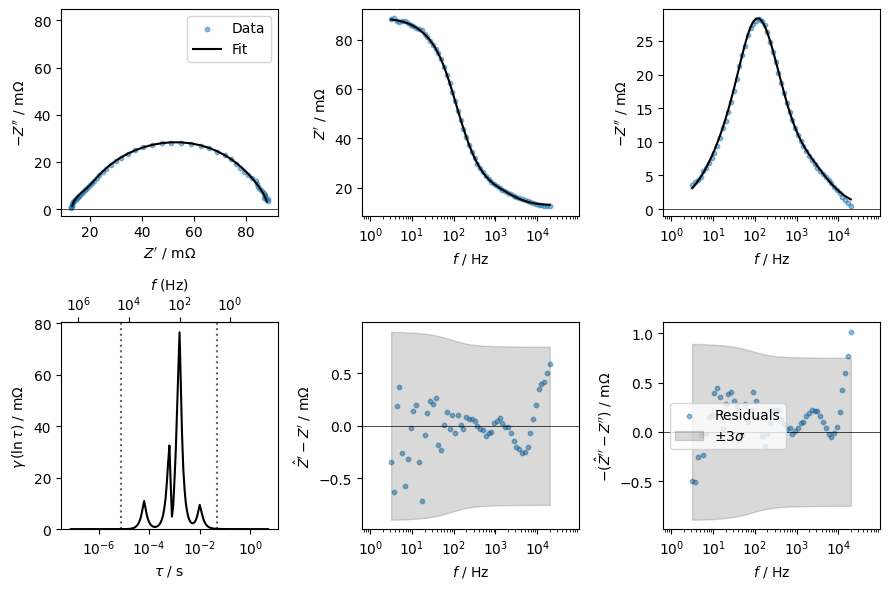

C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')
chain 1 |                                                                                        | 00:00 Status
chain 1 |████████████████████████████▌                            | 00:06 Iteration:   1 / 200 [  0%]  (Warmup)
chain 1 |███████████████████████████████████████████████████████| 00:15 Iteration: 101 / 200 [ 50%]  (Sampling)
chain 1 |████████████████████████████████████████████████████████████████████████████| 00:15 Sampling completed
chain 2 |████████████████████████████████████████████████████████████████████████████| 00:15 Sampling completed


MAP fit time 16.7 s


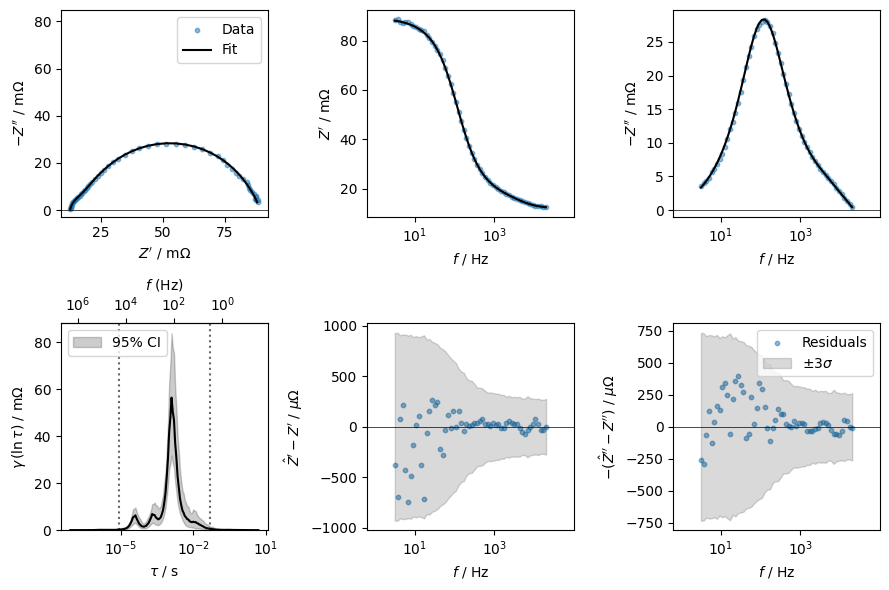

In [22]:
# series += 1
    # freq_vec_old = [1,2]
# file_in = "C:/Users/Herman/Desktop/V_Day3_procedure1_05_PEIS_C01.mpt"
# file_in = r"C:\Users\Herman\Desktop\MFF\Diplomka\Data z PEMWE\049_IV_IV_Ir etched star, Pt 7 nm + C 105 nm etched star\Data z PEMWE\IV_Day5_procedure1_05_PEIS.mpt"
mpr = MPRfile(r"C:\Users\Herman\Desktop\WE\PEM-WE measurements\225_V_V IrOx series 0.1 sccm O2 15 sccm Ar\V_Day4_procedure1_05_PEIS_C01.mpr")
df = (pd.DataFrame(mpr.data))
# skip_rows = get_header_lines(file_in)
# with open(file_in, encoding='latin1') as f:
    # df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,40),delimiter = '\t')
        
unique_vals = np.unique(df["cycle number"].values)

# E = 0
# E_control, booster = get_EIS_setting(file_in)
# print(E_control)


E_control = 'Ewe'

# if cycles is None:
cycles = unique_vals
    # cycles = unique_vals[0::100]
# for i,val in enumerate(cycles):
for val in range(8,9):
    # sample_spectrum_number += 1

    f = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
    # Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
    if E_control == 'Ewe':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
        # E_new = np.mean(df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
    elif E_control == 'Ewe-Ece':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Zwe-ce)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Zwe-ce)/Ohm'].values)
        # E_new = np.mean(df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe-Ece>/V'].values)
        # Z_exp = np.flip(Z_exp)
        # freq_vec = np.flip(freq_vec)
        # I = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<I>/mA'].values)
        # time = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'time/s'].values)
    
    mask = (f > 0) & (f >= 3) & (f <= 2e4)
    mask &= np.isfinite(Z.real) & np.isfinite(Z.imag)


    f = f[mask]
    Z = Z[mask]

    inv = Inverter()
    start = time.time()
    # inv.fit(f, Z, mode='optimize',nonneg = True,outliers = True)
    inv.fit(f, Z, mode='optimize',nonneg = True,outliers = True,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
    elapsed = time.time() - start
    print('MAP fit time {:.1f} s'.format(elapsed))
    inv.plot_full_results()
    plt.show()
    
    
    inv_map = Inverter()
    start = time.time()
    # inv.fit(f, Z, mode='optimize',nonneg = True,outliers = True)
    inv_map.fit(f, Z, mode='sample',nonneg = True,outliers = True,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
    elapsed = time.time() - start
    print('MAP fit time {:.1f} s'.format(elapsed))
    inv_map.plot_full_results()
    plt.show()


C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')
C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\bayes_drt2\inversion.py:1438: UserWarning: Identified likely outliers at indices [[0]], f=[[147110.67]] Hz. An outlier-robust error model will be used. To disable this behavior, pass outliers=False.
  warnings.warn(
11:47:45 - cmdstanpy - INFO - CmdStan start processing
chain 1 |                                                                                        | 00:00 Status
chain 1 |██████████████████████                                                                  | 00:00 Status
chain 1 |██████████████████████████████████████████▊              | 00:18 Iteration: 100 / 200 [ 50%]  (Warmup)
chain 2 |████████████████████████████▌                            | 00:18


11:48:33 - cmdstanpy - INFO - CmdStan done processing.
11:48:33 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: std_normal_lpdf: Random variable[63] is nan, but must be not nan! (in 'Series_outliers.stan', line 65, column 1 to column 21)
	Exception: std_normal_lpdf: Random variable[63] is nan, but must be not nan! (in 'Series_outliers.stan', line 65, column 1 to column 21)
	Exception: std_normal_lpdf: Random variable[63] is nan, but must be not nan! (in 'Series_outliers.stan', line 65, column 1 to column 21)
	Exception: std_normal_lpdf: Random variable[63] is nan, but must be not nan! (in 'Series_outliers.stan', line 65, column 1 to column 21)
	Exception: std_normal_lpdf: Random variable[66] is nan, but must be not nan! (in 'Series_outliers.stan', line 65, column 1 to column 21)
	Exception: std_normal_lpdf: Random variable[66] is nan, but must be not nan! (in 'Series_outliers.stan', line 65, column 1 to column 21)
	Exception: normal_lpdf: Scale parameter[3] is 0, b

array([[<Axes: xlabel='$Z^\\prime \\ / \\ \\mathrm{m}\\Omega$', ylabel='$-Z^{\\prime\\prime} \\ / \\ \\mathrm{m}\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$Z^\\prime$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-$$Z^{\\prime\\prime}$ / m$\\Omega$'>],
       [<Axes: xlabel='$\\tau$ / s', ylabel='$\\gamma \\, (\\ln{\\tau})$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$\\hat{Z}^{\\prime}-Z^{\\prime}$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-(\\hat{Z}^{\\prime\\prime}-Z^{\\prime\\prime})$ / m$\\Omega$'>]],
      dtype=object)

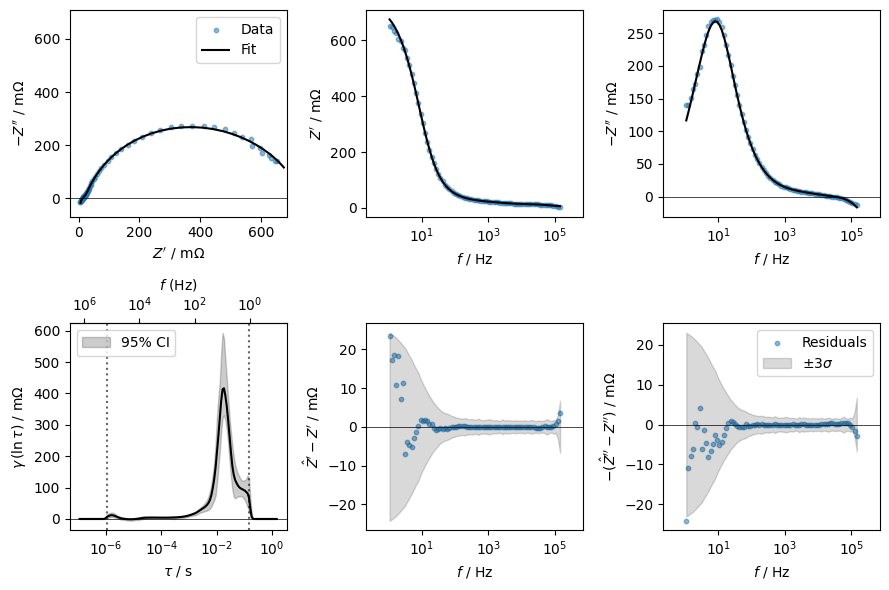

In [9]:
invx = Inverter(f)
invx.fit(f,Z,mode = "sample",outliers = 'auto',warmup = 100, samples = 100, init_from_ridge = True)
invx.plot_full_results()

array([[<Axes: xlabel='$Z^\\prime \\ / \\ \\mathrm{m}\\Omega$', ylabel='$-Z^{\\prime\\prime} \\ / \\ \\mathrm{m}\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$Z^\\prime$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-$$Z^{\\prime\\prime}$ / m$\\Omega$'>],
       [<Axes: xlabel='$\\tau$ / s', ylabel='$\\gamma \\, (\\ln{\\tau})$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$\\hat{Z}^{\\prime}-Z^{\\prime}$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-(\\hat{Z}^{\\prime\\prime}-Z^{\\prime\\prime})$ / m$\\Omega$'>]],
      dtype=object)

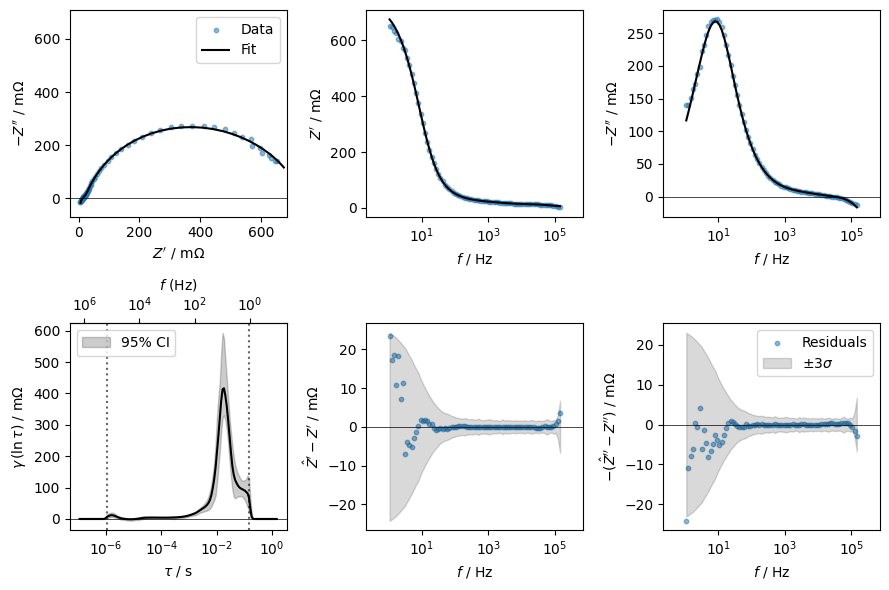

In [10]:
invx.plot_full_results()

In [8]:
plt.plot(inv.tau_plot,inv.distribution_f)
plt.plot(inv_map.tau_plot,inv_map.distribution_f)
plt.xscale('log')

AttributeError: 'Inverter' object has no attribute 'tau_plot'

In [7]:
data = np.loadtxt(r"C:\Users\Herman\Desktop\WE\testDRT\spectra\spectrum1new.txt")
f = data[:,0]
Z = data[:,1] + 1j*data[:,2]

In [15]:
# :

# "Fit the data"
# By default, the Inverter class is configured to fit the DRT (rather than the DDT)
# Create separate Inverter instances for HMC and MAP fits
# Set the basis frequencies equal to the measurement frequencies 
# (not necessary in general, but yields faster results here - see Tutorial 1 for more info on basis_freq)
# inv_hmc = Inverter(basis_freq=f)
inv_map = Inverter(basis_freq=f)

# # Perform HMC fit
# start = time.time()
# inv_hmc.fit(f, Z, mode='sample')
# elapsed = time.time() - start
# print('HMC fit time {:.1f} s'.format(elapsed))

# Perform MAP fit
start = time.time()
inv_map.fit(f, Z, mode='optimize',init_from_ridge = True)  # initialize from ridge solution
elapsed = time.time() - start
print('MAP fit time {:.1f} s'.format(elapsed))



ValueError: Rank(A) < p or Rank([P; A; G]) < n

<Axes: xlabel='$\\tau$ / s', ylabel='$\\gamma \\, (\\ln{\\tau})$ / m$\\Omega$'>

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\plotting.py:595: RuntimeWarning: divide by zero encountered in divide
  return 1 / (2 * np.pi * x)


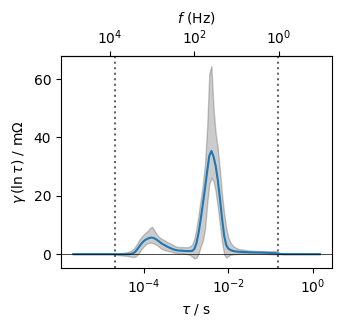

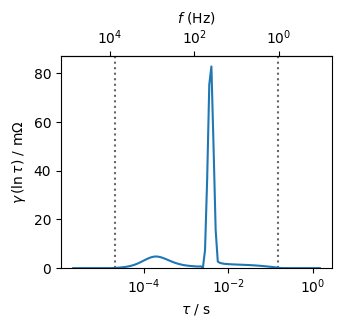

In [24]:
inv_map.plot_distribution()
inv.plot_distribution()

In [69]:
inv.R_inf

0.012154933528481838

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\plotting.py:595: RuntimeWarning: divide by zero encountered in divide
  return 1 / (2 * np.pi * x)


array([[<Axes: xlabel='$Z^\\prime \\ / \\ \\mathrm{m}\\Omega$', ylabel='$-Z^{\\prime\\prime} \\ / \\ \\mathrm{m}\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$Z^\\prime$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-$$Z^{\\prime\\prime}$ / m$\\Omega$'>],
       [<Axes: xlabel='$\\tau$ / s', ylabel='$\\gamma \\, (\\ln{\\tau})$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$\\hat{Z}^{\\prime}-Z^{\\prime}$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-(\\hat{Z}^{\\prime\\prime}-Z^{\\prime\\prime})$ / m$\\Omega$'>]],
      dtype=object)

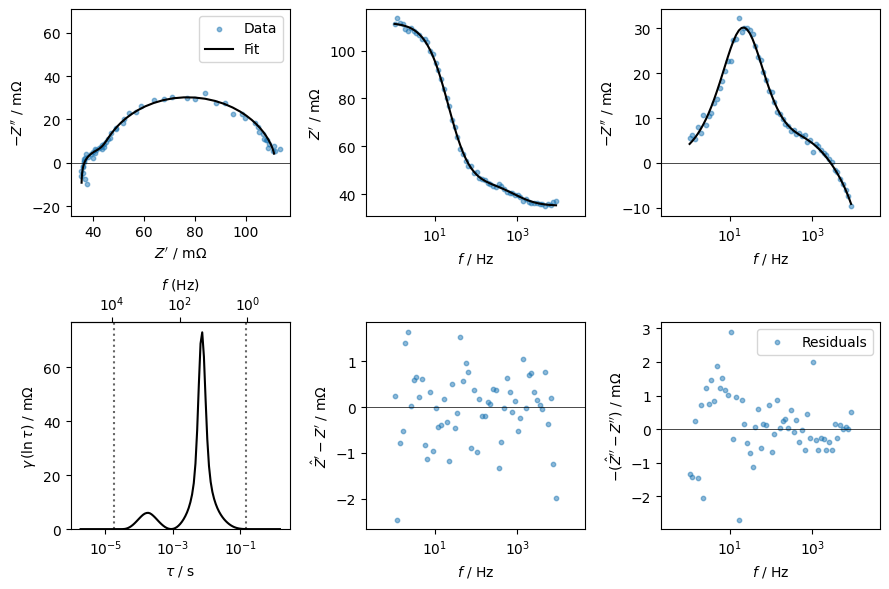

In [19]:
inv2.plot_full_results()

In [8]:
inv.ridge_fit(f,Z,lambda_0='cv',init_from_ridge = True)

TypeError: ridge_fit() got an unexpected keyword argument 'init_from_ridge'

In [10]:
inv.inductance

1.5017302642127037e-08

<Axes: xlabel='$\\tau$ / s', ylabel='$\\gamma \\, (\\ln{\\tau})$ / m$\\Omega$'>

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\plotting.py:595: RuntimeWarning: divide by zero encountered in divide
  return 1 / (2 * np.pi * x)


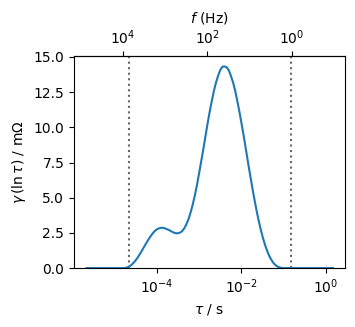

In [25]:
inv2 = Inverter(f)
inv2.ridge_fit(f,Z,nonneg = True,lambda_0 = 'cv',preset = 'Huang',hyper_lambda = False)
inv2.plot_distribution()



C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')
08:53:47 - cmdstanpy - INFO - Chain [1] start processing
08:53:47 - cmdstanpy - INFO - Chain [1] done processing
08:53:47 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release to always return a numpy.ndarray, even for scalar variables.
08:53:47 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release to always return a numpy.ndarray, even for scalar variables.
08:53:47 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release to always return a numpy.ndarray, even for scalar variables.
08:53:47 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release 

<Axes: xlabel='$\\tau$ / s', ylabel='$\\gamma \\, (\\ln{\\tau})$ / m$\\Omega$'>

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\plotting.py:595: RuntimeWarning: divide by zero encountered in divide
  return 1 / (2 * np.pi * x)


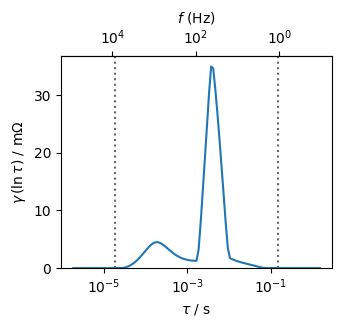

In [12]:
inv3 = Inverter(f)
inv3.fit(f,Z,mode = 'optimize',nonneg = True,init_from_ridge = True)
inv3.plot_distribution()

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\plotting.py:595: RuntimeWarning: divide by zero encountered in divide
  return 1 / (2 * np.pi * x)


array([[<Axes: xlabel='$Z^\\prime \\ / \\ \\mathrm{m}\\Omega$', ylabel='$-Z^{\\prime\\prime} \\ / \\ \\mathrm{m}\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$Z^\\prime$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-$$Z^{\\prime\\prime}$ / m$\\Omega$'>],
       [<Axes: xlabel='$\\tau$ / s', ylabel='$\\gamma \\, (\\ln{\\tau})$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$\\hat{Z}^{\\prime}-Z^{\\prime}$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-(\\hat{Z}^{\\prime\\prime}-Z^{\\prime\\prime})$ / m$\\Omega$'>]],
      dtype=object)

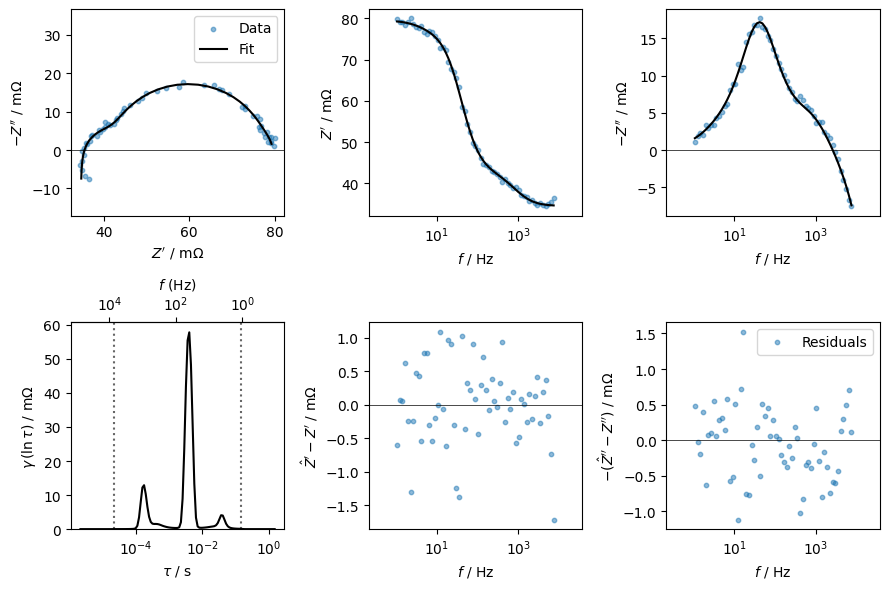

In [37]:
inv3 = Inverter(f)
inv3.ridge_fit(f,Z,lambda_0 = 'cv',hyper_lambda = False)
inv3.plot_full_results()

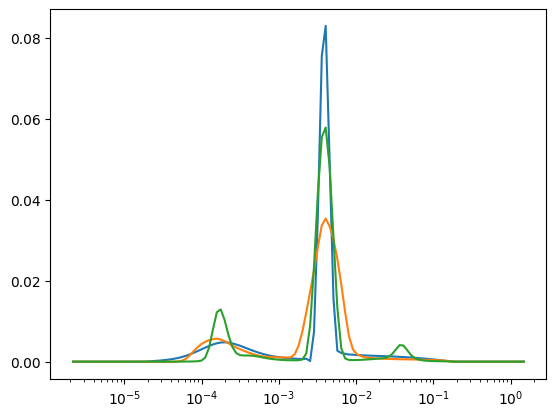

In [38]:
plt.plot(inv.tau_plot,inv.predict_distribution('DRT',inv.tau_plot))
plt.plot(inv_map.tau_plot,inv_map.predict_distribution('DRT',inv_map.tau_plot))
plt.plot(inv3.tau_plot,inv3.predict_distribution('DRT',inv3.tau_plot))
plt.xscale('log')
# inv2.save_fit_data('test3x.pkl')
# plt.xlim(1/20000,1)

<Axes: xlabel='$Z^\\prime \\ / \\ \\mathrm{m}\\Omega$', ylabel='$-Z^{\\prime\\prime} \\ / \\ \\mathrm{m}\\Omega$'>

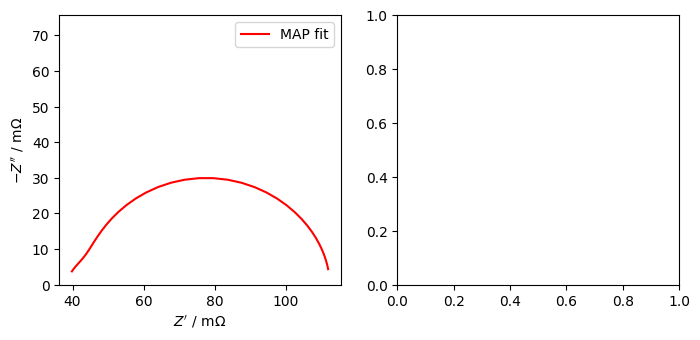

In [11]:
fig,axes = plt.subplots(1, 2, figsize=(8, 3.5))
inv2.plot_fit(axes=axes[0], plot_type='nyquist', color='r', label='MAP fit', plot_data=False)

AttributeError: 'Inverter' object has no attribute 'tau_plot'

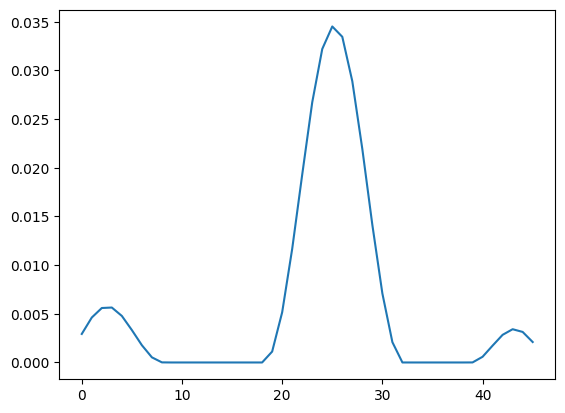

In [12]:
plt.plot(inv.distribution_fits['DRT']['coef'])
plt.plot(inv.tau_plot,inv.distribution_f)
plt.xscale('log')

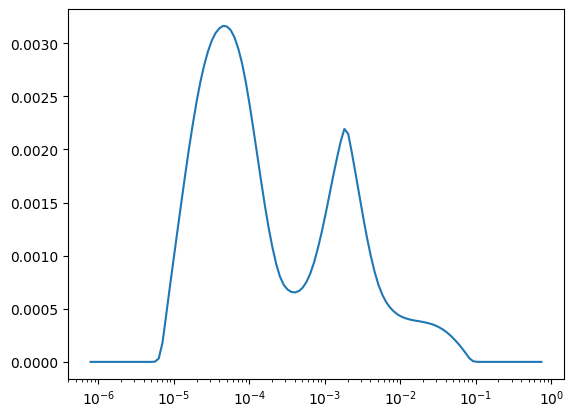

In [34]:
plt.plot(inv.tau_plot,inv.distribution_f)
plt.xscale('log')

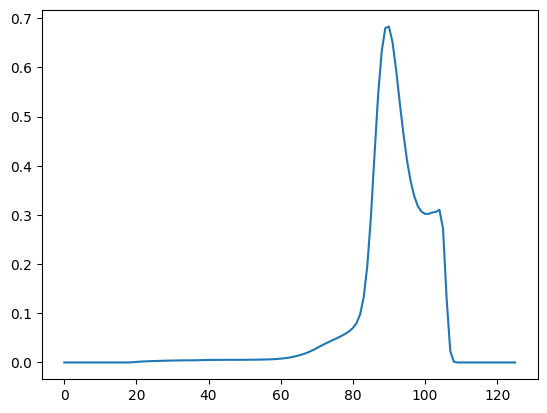

In [131]:
plt.plot(inv.predict_distribution('DRT',inv.tau_plot))

           Freq     Zreal     Zimag      Zmod       Zphz
0   8590.404300  0.037224  0.008473  0.038176  12.822910
1   7374.483900  0.036723  0.006428  0.037282   9.928770
2   6333.793500  0.036278  0.004185  0.036519   6.579905
3   5435.933100  0.035202  0.003047  0.035333   4.947086
4   4670.516600  0.035657  0.001549  0.035690   2.487312
5   4006.154100  0.035480  0.000532  0.035484   0.859436
6   3441.101300  0.035378 -0.001343  0.035403  -2.174403
7   2955.945600  0.036234 -0.002147  0.036297  -3.391794
8   2537.564200  0.036032 -0.003468  0.036199  -5.497494
9   2177.908900  0.036906 -0.004674  0.037201  -7.218190
10  1870.598600  0.037397 -0.006099  0.037891  -9.262041
11  1607.572300  0.038281 -0.006326  0.038800  -9.383591
12  1380.442100  0.039242 -0.007688  0.039989 -11.084647
13  1185.379200  0.039914 -0.009306  0.040984 -13.123539
14  1017.931800  0.043003 -0.011484  0.044510 -14.951987
15   873.044130  0.042833 -0.010307  0.044056 -13.530541
16   750.239930  0.043389 -0.01

array([<Axes: xlabel='$Z^\\prime \\ / \\ \\mathrm{m}\\Omega$', ylabel='$-Z^{\\prime\\prime} \\ / \\ \\mathrm{m}\\Omega$'>,
       <Axes: xlabel='$f$ / Hz', ylabel='$Z^\\prime$ / m$\\Omega$'>,
       <Axes: xlabel='$f$ / Hz', ylabel='$-$$Z^{\\prime\\prime}$ / m$\\Omega$'>],
      dtype=object)

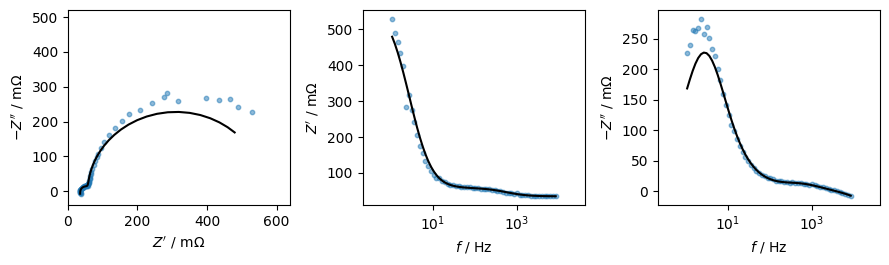

In [11]:
df = fl.construct_eis_df(f,Z)
print(df)
bp.plot_fit(df,inv2)

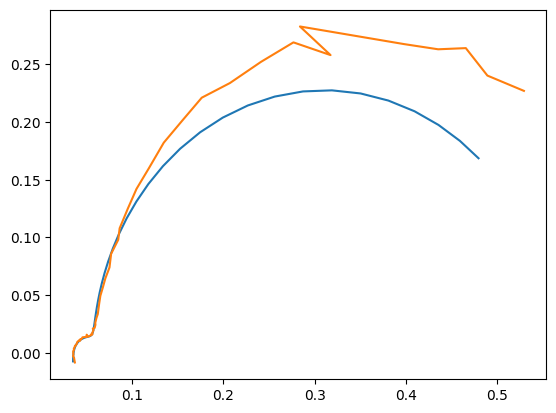

In [10]:
Z_pred = inv2.predict_Z(f)
plt.plot(Z_pred.real, -Z_pred.imag)
plt.plot(Z.real, -Z.imag)